# 10 · Renewal model v2 — hinge price response, FY2023–FY2025, rolled-forward 2026 snapshot

**Why this notebook exists.** The v1 stress tests (notebooks 08/09) looked bad for three separate reasons. Two of them start here, in the renewal model that every downstream number depends on:

1. **The v1 model has one straight-line rate slope.** The historical data (and the brief) show a *kinked* curve: renewal is flat at ~92% for any quote at or below 0%, and only falls for increases (83% at +10%, 68% at +20%, 58% at +25%). A single slope forces the model to say that a −15% cut lifts renewal to ~96% and that a flat quote renews at only ~90%. The optimiser then believes retention can be bought with cuts, and it prices right up to the 80% floor on a curve that is wrong exactly where the floor sits.
2. **The v1 2026 snapshot is one year stale.** Prior-history features were computed "as of the FY2025 decision" (i.e. from FY2023–FY2024 only), and risk/premium were taken at the FY2025 quote. For a 2026 decision the history must include the FY2025 outcome, and risk/premium must be the end-FY2025 values in B1.

The third reason (stress-test arithmetic) is fixed in notebook 12.

**Protocol (unchanged from v1, as required):** develop on FY2023–FY2024, validate out-of-time on FY2025, then refit the chosen specification on **all three years FY2023–FY2025** and score 2026. No B4 field enters the model. FY2025 claims are not a renewal predictor.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' if (ROOT / 'data').exists() else ROOT   # raw input files
sys.path.insert(0, str(ROOT / 'notebooks'))
from trackA_v2_utils import add_history_features, make_features, sigmoid, RATES, RATE_FEATURES

OUT = ROOT / 'outputs' / 'v2' / '01_renewal_model'; (OUT / 'plots').mkdir(parents=True, exist_ok=True)
b1 = pd.read_csv(DATA / 'B1_account_master.csv.gz')
b2 = pd.read_csv(DATA / 'B2_renewal_quote_history.csv.gz')
b2 = add_history_features(b2.merge(b1[['account_id', 'industry', 'rating_region']], on='account_id', validate='many_to_one'))
assert b2.groupby('quote_year').size().eq(7300).all() and b2['quote_year'].between(2023, 2025).all()
PRIOR_FILL = b2.loc[b2.quote_year < 2025, 'renewed_flag'].mean()      # fill for accounts with no history (FY2023 rows)
print(b2.groupby('quote_year').agg(quotes=('account_id', 'size'), renewal_rate=('renewed_flag', 'mean'), mean_rate=('quoted_rate_change_pct', 'mean')))

            quotes  renewal_rate  mean_rate
quote_year                                 
2023          7300      0.838219   6.009589
2024          7300      0.837534   6.026712
2025          7300      0.839589   5.867123


## 1 · Evidence for the kink (raw FY2023–FY2025 data)

In [2]:
bins = [-16, -10.5, -5.5, -0.5, 0.5, 5.5, 10.5, 15.5, 20.5, 25]
b2['rate_bucket'] = pd.cut(b2['quoted_rate_change_pct'], bins)
b2['risk_bucket'] = pd.cut(b2['risk_score_at_quote'], [0, .5, 1, 1.5, 2.5, 5])
raw_curve = b2.groupby('rate_bucket', observed=True)['renewed_flag'].agg(['mean', 'size'])
raw_by_risk = b2.pivot_table(index='rate_bucket', columns='risk_bucket', values='renewed_flag', aggfunc='mean', observed=True)
raw_curve.to_csv(OUT / 'raw_renewal_curve.csv'); raw_by_risk.to_csv(OUT / 'raw_renewal_curve_by_risk.csv')
display(raw_curve.round(3)); display(raw_by_risk.round(3))
# Cuts do not buy retention (flat ~92%); increases lose it, and much faster for low-risk (healthier) accounts.

,mean,size
rate_bucket,,
"(-16.0, -10.5]",0.91,837
"(-10.5, -5.5]",0.92,1319
"(-5.5, -0.5]",0.92,1992
"(-0.5, 0.5]",0.92,3705
"(0.5, 5.5]",0.88,4417
"(5.5, 10.5]",0.83,3947
"(10.5, 15.5]",0.76,2867
"(15.5, 20.5]",0.68,1712
"(20.5, 25.0]",0.58,1104


risk_bucket,"(0.0, 0.5]","(0.5, 1.0]","(1.0, 1.5]","(1.5, 2.5]","(2.5, 5.0]"
rate_bucket,,,,,
"(-16.0, -10.5]",0.876,0.894,0.939,0.947,1.000
"(-10.5, -5.5]",0.854,0.920,0.952,0.973,1.000
"(-5.5, -0.5]",0.851,0.923,0.939,0.995,1.000
"(-0.5, 0.5]",0.862,0.913,0.953,0.981,0.995
"(0.5, 5.5]",0.801,0.868,0.934,0.964,1.000
"(5.5, 10.5]",0.742,0.817,0.869,0.939,0.996
"(10.5, 15.5]",0.627,0.739,0.823,0.938,0.982
"(15.5, 20.5]",0.529,0.647,0.759,0.860,0.983
"(20.5, 25.0]",0.409,0.551,0.592,0.891,1.000


## 2 · Out-of-time challenger test (train FY2023–FY2024 → test FY2025)

Besides the usual discrimination/calibration metrics we score **curve fidelity**: the gap between predicted and actual renewal by offered-rate bucket (and by rate × risk cell). This is the quantity the optimiser actually consumes, so it matters more than AUC.

In [3]:
train, test = b2[b2.quote_year < 2025].copy(), b2[b2.quote_year == 2025].copy()
test['rb'] = pd.cut(test['quoted_rate_change_pct'], [-16, -0.5, 0.5, 5.5, 10.5, 15.5, 20.5, 25])

def fit_logit(df, spec):
    X = make_features(df, spec, PRIOR_FILL); mu, sd = X.mean(), X.std().replace(0, 1)
    m = LogisticRegression(C=1.0, max_iter=5000).fit((X - mu) / sd, df['renewed_flag'])
    return m, X.columns, mu, sd

def predict_logit(obj, df, spec):
    m, cols, mu, sd = obj
    X = make_features(df, spec, PRIOR_FILL).reindex(columns=cols, fill_value=0)
    return m.predict_proba((X - mu) / sd)[:, 1]

def score(name, p):
    t = test.assign(p=p)
    curve = t.groupby('rb', observed=True).agg(actual=('renewed_flag', 'mean'), pred=('p', 'mean'))
    cell = t.groupby(['rb', 'risk_bucket'], observed=True).agg(a=('renewed_flag', 'mean'), p=('p', 'mean'), n=('p', 'size'))
    return dict(model=name, roc_auc=roc_auc_score(t.renewed_flag, p), log_loss=log_loss(t.renewed_flag, p),
                brier=brier_score_loss(t.renewed_flag, p),
                rate_curve_mae_pts=100 * (curve.actual - curve.pred).abs().mean(),
                rate_x_risk_cell_mae_pts=100 * np.average((cell.a - cell.p).abs(), weights=cell.n),
                cut_bucket_bias_pts=100 * (curve.pred.iloc[0] - curve.actual.iloc[0])), curve

results, curves = [], {}
for spec, name in [('linear', 'v1 logistic, single rate slope'), ('hinge', 'v2 logistic, hinge rate response')]:
    s, curves[name] = score(name, predict_logit(fit_logit(train, spec), test, spec)); results.append(s)
gb_cols = ['quoted_rate_change_pct', 'risk_score_at_quote']
gbm = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=3, monotonic_cst=[-1, 1], random_state=0)
gbm.fit(train[gb_cols], train['renewed_flag'])
s, curves['GBM challenger (monotone in rate)'] = score('GBM challenger (monotone in rate)', gbm.predict_proba(test[gb_cols])[:, 1]); results.append(s)
oot = pd.DataFrame(results); oot.to_csv(OUT / 'oot_model_comparison.csv', index=False)
display(oot.round(4))

,model,roc_auc,log_loss,brier,rate_curve_mae_pts,rate_x_risk_cell_mae_pts,cut_bucket_bias_pts
0,"v1 logistic, single rate slope",0.7396,0.3879,0.1199,2.0852,2.2164,2.2623
1,"v2 logistic, hinge rate response",0.7430,0.3854,0.1195,0.2674,1.0373,-0.2480
2,GBM challenger (monotone in rate),0.7456,0.3839,0.1189,0.4608,1.2955,-0.1524


**Reading.** The hinge logistic keeps (slightly improves) AUC/log-loss versus v1, but cuts the rate-curve error by roughly an order of magnitude (≈2.1 pts → ≈0.3 pts) and removes the +2.3 pt over-prediction in the cut bucket. The monotone GBM has marginally better AUC but a worse curve, is harder to explain, and its rate response cannot be stressed parametrically. **Selected: hinge logistic.**

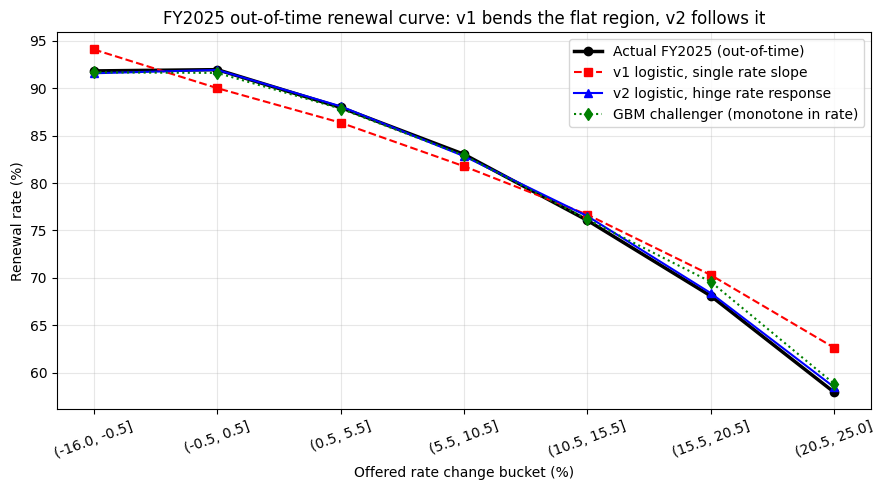

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(next(iter(curves.values()))))
labels = [str(i) for i in next(iter(curves.values())).index]
ax.plot(x, 100 * curves['v1 logistic, single rate slope']['actual'], 'ko-', lw=2.5, label='Actual FY2025 (out-of-time)')
for name, style in [('v1 logistic, single rate slope', 'r--s'), ('v2 logistic, hinge rate response', 'b-^'), ('GBM challenger (monotone in rate)', 'g:d')]:
    ax.plot(x, 100 * curves[name]['pred'], style, label=name)
ax.set_xticks(x, labels, rotation=20); ax.set_ylabel('Renewal rate (%)'); ax.set_xlabel('Offered rate change bucket (%)')
ax.set_title('FY2025 out-of-time renewal curve: v1 bends the flat region, v2 follows it'); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'plots' / '01_oot_renewal_curve_v1_vs_v2.png', dpi=170); plt.show()

## 3 · Final model: refit on all three years (FY2023–FY2025)

We also keep the coefficient covariance (inverse Hessian of the penalised likelihood) and draw 300 parameter vectors from it. Notebook 12 uses those draws so the Monte Carlo reflects *model* uncertainty, not just the coin-flip of each account renewing.

In [5]:
final_obj = fit_logit(b2, 'hinge'); final_model, cols, mu, sd = final_obj
Z = ((make_features(b2, 'hinge', PRIOR_FILL) - mu) / sd).to_numpy()
beta = np.r_[final_model.intercept_, final_model.coef_[0]]
Z1 = np.c_[np.ones(len(Z)), Z]; pz = sigmoid(Z1 @ beta)
H = (Z1 * (pz * (1 - pz))[:, None]).T @ Z1 + np.diag(np.r_[0, np.ones(Z.shape[1])])   # C=1 ridge on slopes
cov = np.linalg.inv(H)
beta_draws = beta + np.random.default_rng(7).standard_normal((300, len(beta))) @ np.linalg.cholesky(cov).T
coef = pd.DataFrame({'feature': ['intercept'] + list(cols), 'coef_standardised': beta, 'std_error': np.sqrt(np.diag(cov)),
                     'raw_mean': np.r_[np.nan, mu.values], 'raw_sd': np.r_[np.nan, sd.values]})
coef.to_csv(OUT / 'final_hinge_model_coefficients.csv', index=False)
display(coef.head(11).round(4))
rate_idx = [1 + list(cols).index(f) for f in RATE_FEATURES]     # column positions of the rate terms in Z1
print('rate term positions:', dict(zip(RATE_FEATURES, rate_idx)))
# rate_neg coefficient is ~0: price cuts do not buy renewals. rate_pos is strongly negative.

,feature,coef_standardised,std_error,raw_mean,raw_sd
0,intercept,2.0531,0.0279,NaN,NaN
1,rate_pos,-0.6580,0.0725,7.5982,7.5873
2,rate_neg,0.0174,0.0289,-1.6304,3.7734
3,rate_pos2,-0.0093,0.0586,4.6119,6.6288
4,rate_pos_x_risk,-0.0231,0.0680,7.8145,12.2971
5,risk,1.0914,0.0692,1.0329,0.8799
6,log_premium,-0.0101,0.0197,14.2394,0.7213
7,prior_renewal_rate,-0.0213,0.0193,0.8380,0.2622
8,prior_rate_mean,-0.0975,0.0424,4.0092,7.4732
9,prior_rate_last,0.0757,0.0413,4.0121,8.5164


rate term positions: {'rate_pos': 1, 'rate_neg': 2, 'rate_pos2': 3, 'rate_pos_x_risk': 4}


## 4 · 2026 scoring snapshot (rolled forward) and the 7,300 × 41 grid

| Feature | v1 snapshot | v2 snapshot (2026 decision) |
|---|---|---|
| prior renewal rate | FY2023–FY2024 | **FY2023–FY2025** |
| prior mean rate / last rate | FY2023–FY2024 / FY2024 | **FY2023–FY2025 / FY2025** |
| risk score | FY2025 *quote-time* | **risk_score_2025 (B1, end of year)** |
| premium | FY2025 quoted premium (held fixed across actions) | **annual_premium_2025 (B1)**, i.e. the in-force base the 2026 change applies to |

In [6]:
claims = pd.read_csv(DATA / 'B3_claims_experience_details.csv.gz', usecols=['account_id', 'paid_amount'])
acct_claims = claims.groupby('account_id')['paid_amount'].agg(paid_claims_2025='sum', sum_sq=lambda s: (s ** 2).sum(), episodes='size')
acct_claims['process_cv'] = np.sqrt(acct_claims['sum_sq']) / acct_claims['paid_claims_2025']   # Poisson-bootstrap cv of each account's claims
hist = b2.groupby('account_id').agg(prior_renewal_rate=('renewed_flag', 'mean'), prior_rate_mean=('quoted_rate_change_pct', 'mean'))
last = b2[b2.quote_year == 2025].set_index('account_id')['quoted_rate_change_pct'].rename('prior_rate_last')
snap = b1.set_index('account_id').join(hist).join(last).join(acct_claims[['paid_claims_2025', 'process_cv']]).reset_index()
snap[['paid_claims_2025', 'process_cv']] = snap[['paid_claims_2025', 'process_cv']].fillna(0)
snap = snap.sort_values('account_id').reset_index(drop=True)
assert len(snap) == 7300 and snap['prior_rate_last'].notna().all()
print(f"FY2025 premium ${snap.annual_premium_2025.sum()/1e9:.3f}bn, paid claims ${snap.paid_claims_2025.sum()/1e9:.3f}bn, "
      f"case MLR {snap.paid_claims_2025.sum()/snap.annual_premium_2025.sum():.1%}")

grid = snap.loc[snap.index.repeat(len(RATES))].reset_index(drop=True)
grid['quoted_rate_change_pct'] = np.tile(RATES, len(snap))
grid['risk_score_at_quote'] = grid['risk_score_2025']
grid['base_premium'] = grid['annual_premium_2025']
Zg = np.c_[np.ones(len(grid)), ((make_features(grid, 'hinge', PRIOR_FILL).reindex(columns=cols, fill_value=0) - mu) / sd).to_numpy()]
Zg = Zg.reshape(len(snap), len(RATES), -1).astype(np.float32)
P = sigmoid(Zg.astype(float) @ beta)
check = pd.DataFrame({'rate': RATES, 'mean_2026_renewal_prob': P.mean(0)}).set_index('rate')
display(check.loc[[-10, 0, 10, 20, 25]].T.round(3))      # brief: 92% / 92% / 83% / 68% / 58%

FY2025 premium $15.000bn, paid claims $13.305bn, case MLR 88.7%


rate,-10,0,10,20,25
mean_2026_renewal_prob,0.916,0.919,0.829,0.678,0.584


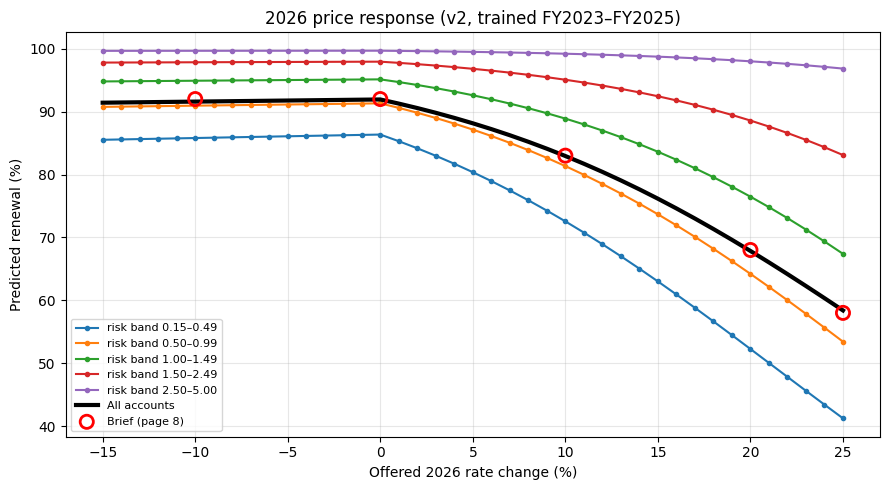

Saved ['account_snapshot_2026_v2.csv', 'final_hinge_model_coefficients.csv', 'grid_2026_v2.npz', 'oot_model_comparison.csv', 'plots', 'raw_renewal_curve.csv', 'raw_renewal_curve_by_risk.csv', 'renewal_probability_grid_2026_v2.csv.gz']


In [7]:
np.savez_compressed(OUT / 'grid_2026_v2.npz', P=P, Zg=Zg, beta=beta, beta_draws=beta_draws, rate_idx=np.array(rate_idx),
                    rates=RATES, account_id=snap['account_id'].to_numpy())
snap.to_csv(OUT / 'account_snapshot_2026_v2.csv', index=False)
pd.DataFrame(P, columns=[f'p_{r}' for r in RATES]).assign(account_id=snap['account_id']).to_csv(OUT / 'renewal_probability_grid_2026_v2.csv.gz', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for band, g in snap.groupby('risk_band'):
    ax.plot(RATES, 100 * P[g.index].mean(0), marker='.', label=f'risk band {band}')
ax.plot(RATES, 100 * P.mean(0), 'k-', lw=3, label='All accounts')
ax.scatter([-10, 0, 10, 20, 25], [92, 92, 83, 68, 58], s=90, facecolors='none', edgecolors='r', lw=2, zorder=5, label='Brief (page 8)')
ax.set_xlabel('Offered 2026 rate change (%)'); ax.set_ylabel('Predicted renewal (%)'); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title('2026 price response (v2, trained FY2023–FY2025)')
fig.tight_layout(); fig.savefig(OUT / 'plots' / '02_2026_price_response_by_risk_band.png', dpi=170); plt.show()
print('Saved', sorted(p.name for p in OUT.iterdir()))